# 04 교수님 피드백 추가 확인

과제2 제출 후 받은 피드백을 바탕으로 몇 가지 내용을 다시 확인한다.

확인할 내용은 confusion matrix, feature importance, class weight 비교,
그리고 고혈압 관련 추가 변수이다.

## 1. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option('display.max_columns', 60)

In [2]:
from pycaret.classification import *

## 2. 데이터 불러오기

과제2 notebook과 같은 방식으로 KNHANES 원본 데이터를 다시 불러온다.

In [3]:
data_dir = Path('분석데이터원본')
sav_files = sorted(data_dir.glob('HN*_all.sav'))

print(len(sav_files))
sav_files

7


[WindowsPath('분석데이터원본/HN17_all.sav'),
 WindowsPath('분석데이터원본/HN18_all.sav'),
 WindowsPath('분석데이터원본/HN19_all.sav'),
 WindowsPath('분석데이터원본/HN20_all.sav'),
 WindowsPath('분석데이터원본/HN21_all.sav'),
 WindowsPath('분석데이터원본/HN22_all.sav'),
 WindowsPath('분석데이터원본/HN23_all.sav')]

In [4]:
use_cols = [
    'age', 'sex',
    'HE_BMI', 'HE_glu', 'HE_TG',
    'sm_presnt', 'dr_month', 'pa_aerobic',
    'incm', 'educ',
    'HE_sbp', 'HE_dbp',
]

In [5]:
df_list = []

for file in sav_files:
    year = 2000 + int(file.name[2:4])
    print(file.name, year)

    temp = pd.read_spss(file, usecols=use_cols)
    temp['year'] = year
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
df.shape

HN17_all.sav 2017


HN18_all.sav 2018


HN19_all.sav 2019


HN20_all.sav 2020


HN21_all.sav 2021


HN22_all.sav 2022


HN23_all.sav 2023


(51872, 13)

In [6]:
df['covid_period'] = 'before'
df.loc[df['year'].isin([2020, 2021]), 'covid_period'] = 'during'
df.loc[df['year'].isin([2022, 2023]), 'covid_period'] = 'after'

df[['year', 'covid_period']].head()

,year,covid_period
0,2017,before
1,2017,before
2,2017,before
3,2017,before
4,2017,before


## 3. 검토 데이터 만들기

메일에 공유한 결과는 SBP/DBP 결측이 없는 대상자를 기준으로 확인했다.
그래서 19-39세 대상자 중 혈압 측정값이 있는 사람만 따로 정리한다.

In [7]:
df_young = df[(df['age'] >= 19) & (df['age'] <= 39)].copy()
df_young.shape

(10974, 14)

In [8]:
df_young['hypertension'] = 0
df_young.loc[
    (df_young['HE_sbp'] >= 140) | (df_young['HE_dbp'] >= 90),
    'hypertension'
] = 1

df_young['hypertension'].value_counts()

hypertension
0    10399
1      575
Name: count, dtype: int64

In [9]:
review_df = df_young.dropna(subset=['HE_sbp', 'HE_dbp']).copy()

print('과제2 원래 데이터:', len(df_young))
print('검토 데이터:', len(review_df))
review_df['hypertension'].value_counts()

과제2 원래 데이터: 10974
검토 데이터: 10319


hypertension
0    9744
1     575
Name: count, dtype: int64

In [10]:
output_dir = Path('processed_data')
output_dir.mkdir(exist_ok=True)

save_path = output_dir / 'knhanes_young_hypertension_2017_2023.csv'
review_df.to_csv(save_path, index=False, encoding='utf-8-sig')

save_path

WindowsPath('processed_data/knhanes_young_hypertension_2017_2023.csv')

## 4. Feature와 target 선택

과제2 모델에서 사용한 변수를 먼저 선택한다.

In [11]:
features = [
    'age', 'sex', 'HE_BMI', 'HE_glu', 'HE_TG',
    'sm_presnt', 'dr_month', 'pa_aerobic',
    'incm', 'educ', 'covid_period'
]

target = 'hypertension'

model_df = review_df[features + [target]].copy()
model_df.head()

,age,sex,HE_BMI,HE_glu,HE_TG,sm_presnt,dr_month,pa_aerobic,incm,educ,covid_period,hypertension
2,39.0,1.0,21.268015,85.0,93.0,1.0,1.0,0.0,1.0,7.0,before,0
3,35.0,2.0,20.292201,86.0,98.0,0.0,1.0,0.0,1.0,7.0,before,0
8,28.0,2.0,21.950821,98.0,103.0,0.0,1.0,1.0,1.0,7.0,before,0
12,37.0,2.0,21.538187,86.0,42.0,1.0,1.0,0.0,1.0,6.0,before,0
19,33.0,2.0,20.885981,79.0,150.0,0.0,0.0,0.0,2.0,7.0,before,0


In [12]:
model_df.isnull().sum()

age               0
sex               0
HE_BMI           39
HE_glu          219
HE_TG           218
sm_presnt        52
dr_month         51
pa_aerobic      423
incm             29
educ              3
covid_period      0
hypertension      0
dtype: int64

In [13]:
model_df['hypertension'].value_counts()

hypertension
0    9744
1     575
Name: count, dtype: int64

## 5. 결측치 처리

과제2 notebook과 같이 수치형은 median, 범주형은 mode로 대체한다.

In [14]:
num_cols = ['age', 'HE_BMI', 'HE_glu', 'HE_TG']
cat_cols = ['sex', 'sm_presnt', 'dr_month', 'pa_aerobic', 'incm', 'educ', 'covid_period']

for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in cat_cols:
    model_df[col] = model_df[col].fillna(model_df[col].mode()[0])

model_df.isnull().sum()

age             0
sex             0
HE_BMI          0
HE_glu          0
HE_TG           0
sm_presnt       0
dr_month        0
pa_aerobic      0
incm            0
educ            0
covid_period    0
hypertension    0
dtype: int64

## 6. educ=99 확인

Feature importance에서 `educ_99.0`이 보였기 때문에, 이 값이 어디서 나온 것인지 확인한다.

In [15]:
educ_check = pd.DataFrame({
    '항목': [
        'educ=99 수',
        'educ 결측 수',
        'educ mode 값',
        '결측 대체 후 educ=99 수'
    ],
    '값': [
        (review_df['educ'] == 99).sum(),
        review_df['educ'].isnull().sum(),
        review_df['educ'].mode()[0],
        (model_df['educ'] == 99).sum()
    ]
})

educ_check

,항목,값
0,educ=99 수,291.0
1,educ 결측 수,3.0
2,educ mode 값,7.0
3,결측 대체 후 educ=99 수,291.0


`educ=99`는 결측치 대체 때문에 만들어진 값이 아니라 원자료에 있던 값으로 보인다.
따라서 이후 분석에서는 codebook을 확인한 뒤 다시 처리할 필요가 있다.

## 7. PyCaret setup

03 notebook과 같은 방식으로 PyCaret setup을 실행한다.
여기서는 Logistic Regression을 다시 확인하기 위해 class weight를 적용한다.

In [16]:
clf_weight = setup(
    data=model_df,
    target='hypertension',
    categorical_features=cat_cols,
    numeric_features=num_cols,
    session_id=123,
    train_size=0.8,
    normalize=True,
    normalize_method='robust',
    fix_imbalance=False,
    fold=5,
    verbose=True
)

,Description,Value
0,Session id,123
1,Target,hypertension
2,Target type,Binary
3,Original data shape,"(10319, 12)"
4,Transformed data shape,"(10319, 24)"
5,Transformed train set shape,"(8255, 24)"
6,Transformed test set shape,"(2064, 24)"
7,Numeric features,4
8,Categorical features,7
9,Preprocess,True


## 8. Class weight 모델 확인

In [17]:
lr_weight = create_model(
    'lr',
    class_weight='balanced'
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7244,0.8213,0.7826,0.1420,0.2404,0.1613,0.2504
1,0.7480,0.7809,0.6739,0.1384,0.2296,0.1511,0.2199
2,0.7505,0.8476,0.7717,0.1537,0.2563,0.1801,0.2662
3,0.7323,0.8149,0.7500,0.1414,0.2379,0.1591,0.2419
4,0.7511,0.8219,0.7391,0.1495,0.2486,0.1719,0.2520
Mean,0.7412,0.8173,0.7435,0.1450,0.2426,0.1647,0.2461
Std,0.0109,0.0214,0.0380,0.0057,0.0092,0.0102,0.0152


In [18]:
weight_cv_results = pull()
weight_cv_results

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7244,0.8213,0.7826,0.1420,0.2404,0.1613,0.2504
1,0.7480,0.7809,0.6739,0.1384,0.2296,0.1511,0.2199
2,0.7505,0.8476,0.7717,0.1537,0.2563,0.1801,0.2662
3,0.7323,0.8149,0.7500,0.1414,0.2379,0.1591,0.2419
4,0.7511,0.8219,0.7391,0.1495,0.2486,0.1719,0.2520
Mean,0.7412,0.8173,0.7435,0.1450,0.2426,0.1647,0.2461
Std,0.0109,0.0214,0.0380,0.0057,0.0092,0.0102,0.0152


In [19]:
tuned_weight = tune_model(
    lr_weight,
    optimize='AUC'
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7250,0.8216,0.7609,0.1394,0.2357,0.1562,0.2412
1,0.7517,0.7818,0.6739,0.1403,0.2322,0.1542,0.2229
2,0.7523,0.8491,0.7717,0.1547,0.2577,0.1817,0.2677
3,0.7347,0.8159,0.7500,0.1426,0.2396,0.1610,0.2438
4,0.7529,0.8218,0.7391,0.1504,0.2500,0.1735,0.2535
Mean,0.7433,0.8180,0.7391,0.1455,0.2430,0.1653,0.2458
Std,0.0114,0.0215,0.0344,0.0060,0.0095,0.0106,0.0148


Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [20]:
weight_tune_results = pull()
weight_tune_results

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7250,0.8216,0.7609,0.1394,0.2357,0.1562,0.2412
1,0.7517,0.7818,0.6739,0.1403,0.2322,0.1542,0.2229
2,0.7523,0.8491,0.7717,0.1547,0.2577,0.1817,0.2677
3,0.7347,0.8159,0.7500,0.1426,0.2396,0.1610,0.2438
4,0.7529,0.8218,0.7391,0.1504,0.2500,0.1735,0.2535
Mean,0.7433,0.8180,0.7391,0.1455,0.2430,0.1653,0.2458
Std,0.0114,0.0215,0.0344,0.0060,0.0095,0.0106,0.0148


## 9. Confusion Matrix 확인

PyCaret holdout prediction 결과를 이용해 confusion matrix를 계산한다.

In [21]:
weight_pred = predict_model(tuned_weight)
weight_pred.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7422,0.8198,0.7217,0.1424,0.2378,0.1596,0.2370


,age,sex,HE_BMI,HE_glu,HE_TG,sm_presnt,dr_month,pa_aerobic,incm,educ,covid_period,hypertension,prediction_label,prediction_score
31909,25.0,1.0,27.894556,82.0,109.0,0.0,0.0,0.0,1.0,8.0,during,0,1,0.5266
3092,33.0,1.0,18.046434,88.0,144.0,0.0,1.0,0.0,2.0,7.0,before,0,0,0.6635
3106,32.0,1.0,26.320131,88.0,91.0,0.0,1.0,1.0,3.0,8.0,before,0,1,0.5904
1261,25.0,2.0,22.442196,89.0,77.0,0.0,1.0,1.0,2.0,6.0,before,0,0,0.8073
24017,25.0,1.0,20.758512,97.0,84.0,1.0,1.0,0.0,4.0,6.0,before,0,0,0.6203


In [22]:
label_col = 'prediction_label'
score_col = 'prediction_score'

weight_pred[[target, label_col, score_col]].head()

,hypertension,prediction_label,prediction_score
31909,0,1,0.5266
3092,0,0,0.6635
3106,0,1,0.5904
1261,0,0,0.8073
24017,0,0,0.6203


In [23]:
cm = pd.crosstab(
    weight_pred[target],
    weight_pred[label_col],
    rownames=['Actual'],
    colnames=['Predicted']
)

cm

Predicted,0,1
Actual,,
0,1449,500
1,32,83


In [24]:
tn = cm.loc[0, 0]
fp = cm.loc[0, 1]
fn = cm.loc[1, 0]
tp = cm.loc[1, 1]

precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * precision * recall / (precision + recall)
pred_pos_rate = (tp + fp) / (tn + fp + fn + tp)

cm_metrics = pd.DataFrame({
    'Metric': ['TN', 'FP', 'FN', 'TP', 'Precision', 'Recall', 'Specificity', 'F1', 'Predicted positive rate'],
    'Value': [tn, fp, fn, tp, precision, recall, specificity, f1, pred_pos_rate]
})

cm_metrics

,Metric,Value
0,TN,1449.000000
1,FP,500.000000
2,FN,32.000000
3,TP,83.000000
4,Precision,0.142367
5,Recall,0.721739
6,Specificity,0.743458
7,F1,0.237822
8,Predicted positive rate,0.282461


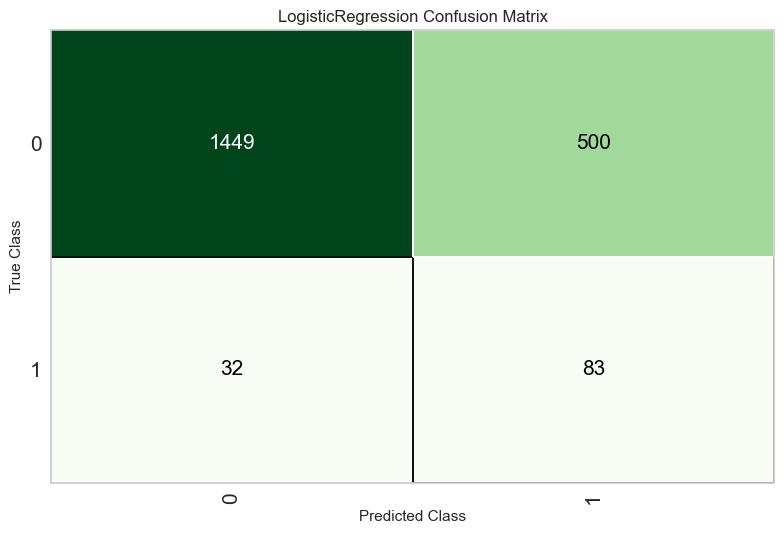

In [25]:
plot_model(tuned_weight, plot='confusion_matrix')

모델이 모든 사람을 정상군으로만 예측한 것은 아니었다.
다만 FP가 많아서 precision은 낮게 나타났다.

## 10. ROC Curve와 Feature Importance 확인

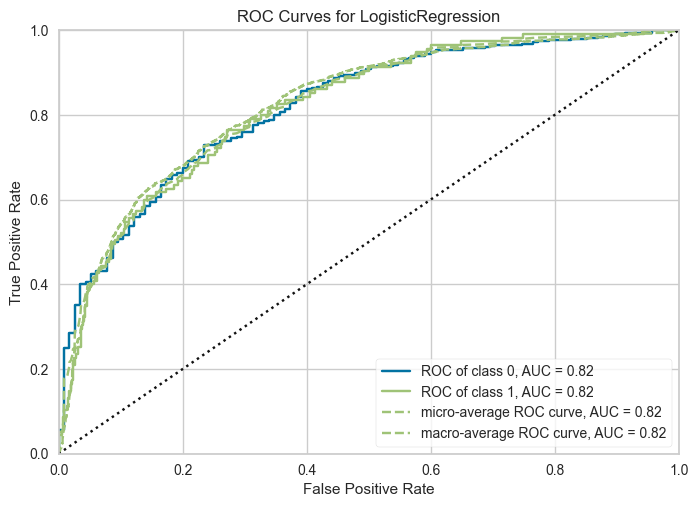

In [26]:
plot_model(tuned_weight, plot='auc')

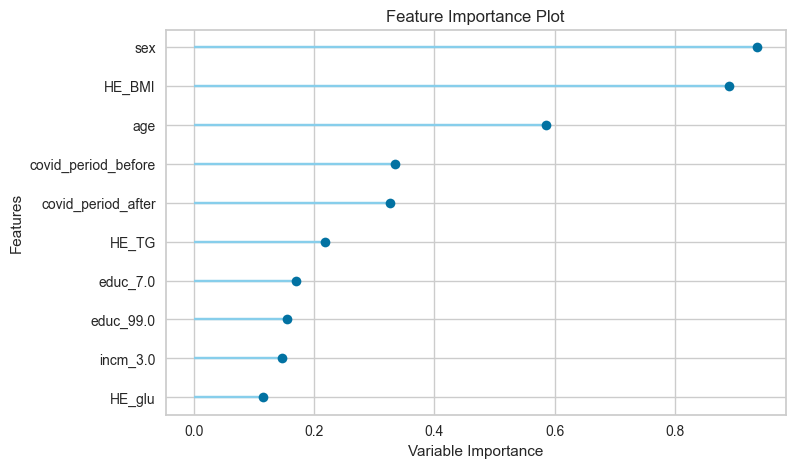

In [27]:
plot_model(tuned_weight, plot='feature')

Feature importance는 모델이 어떤 변수를 많이 사용했는지 보기 위한 참고 자료이다.
인과관계를 의미하지는 않는다.

## 11. SMOTE + class weight 비교

교수님 피드백에 따라 SMOTE와 class weight를 같이 적용한 경우도 확인한다.

In [28]:
clf_smote_weight = setup(
    data=model_df,
    target='hypertension',
    categorical_features=cat_cols,
    numeric_features=num_cols,
    session_id=123,
    train_size=0.8,
    normalize=True,
    normalize_method='robust',
    fix_imbalance=True,
    fold=5,
    verbose=True
)

,Description,Value
0,Session id,123
1,Target,hypertension
2,Target type,Binary
3,Original data shape,"(10319, 12)"
4,Transformed data shape,"(17654, 24)"
5,Transformed train set shape,"(15590, 24)"
6,Transformed test set shape,"(2064, 24)"
7,Numeric features,4
8,Categorical features,7
9,Preprocess,True


In [29]:
lr_smote_weight = create_model(
    'lr',
    class_weight='balanced'
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7256,0.8180,0.7826,0.1426,0.2412,0.1622,0.2513
1,0.7547,0.7810,0.6848,0.1435,0.2373,0.1599,0.2303
2,0.7480,0.8463,0.7609,0.1509,0.2518,0.1751,0.2593
3,0.7293,0.8118,0.7391,0.1385,0.2333,0.1539,0.2348
4,0.7474,0.8183,0.7391,0.1475,0.2459,0.1687,0.2490
Mean,0.7410,0.8151,0.7413,0.1446,0.2419,0.1639,0.2450
Std,0.0114,0.0208,0.0325,0.0042,0.0065,0.0073,0.0108


In [30]:
smote_cv_results = pull()
smote_cv_results

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7256,0.8180,0.7826,0.1426,0.2412,0.1622,0.2513
1,0.7547,0.7810,0.6848,0.1435,0.2373,0.1599,0.2303
2,0.7480,0.8463,0.7609,0.1509,0.2518,0.1751,0.2593
3,0.7293,0.8118,0.7391,0.1385,0.2333,0.1539,0.2348
4,0.7474,0.8183,0.7391,0.1475,0.2459,0.1687,0.2490
Mean,0.7410,0.8151,0.7413,0.1446,0.2419,0.1639,0.2450
Std,0.0114,0.0208,0.0325,0.0042,0.0065,0.0073,0.0108


In [31]:
tuned_smote_weight = tune_model(
    lr_smote_weight,
    optimize='AUC'
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7286,0.8190,0.7609,0.1411,0.2381,0.1590,0.2440
1,0.7577,0.7819,0.6848,0.1452,0.2395,0.1625,0.2328
2,0.7486,0.8473,0.7609,0.1512,0.2523,0.1756,0.2598
3,0.7286,0.8124,0.7391,0.1382,0.2329,0.1534,0.2343
4,0.7480,0.8188,0.7500,0.1494,0.2491,0.1722,0.2544
Mean,0.7423,0.8159,0.7391,0.1450,0.2424,0.1645,0.2451
Std,0.0117,0.0208,0.0283,0.0049,0.0072,0.0082,0.0107


Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [32]:
smote_tune_results = pull()
smote_tune_results

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7286,0.8190,0.7609,0.1411,0.2381,0.1590,0.2440
1,0.7577,0.7819,0.6848,0.1452,0.2395,0.1625,0.2328
2,0.7486,0.8473,0.7609,0.1512,0.2523,0.1756,0.2598
3,0.7286,0.8124,0.7391,0.1382,0.2329,0.1534,0.2343
4,0.7480,0.8188,0.7500,0.1494,0.2491,0.1722,0.2544
Mean,0.7423,0.8159,0.7391,0.1450,0.2424,0.1645,0.2451
Std,0.0117,0.0208,0.0283,0.0049,0.0072,0.0082,0.0107


In [33]:
smote_pred = predict_model(tuned_smote_weight)
smote_pred[[target, label_col, score_col]].head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7427,0.8202,0.7217,0.1426,0.2382,0.1600,0.2374


,hypertension,prediction_label,prediction_score
31909,0,1,0.5037
3092,0,0,0.6695
3106,0,1,0.6083
1261,0,0,0.8262
24017,0,0,0.6283


In [34]:
smote_cm = pd.crosstab(
    smote_pred[target],
    smote_pred[label_col],
    rownames=['Actual'],
    colnames=['Predicted']
)

smote_cm

Predicted,0,1
Actual,,
0,1450,499
1,32,83


In [35]:
smote_cm = pd.crosstab(
    smote_pred[target],
    smote_pred[label_col],
    rownames=['Actual'],
    colnames=['Predicted']
)

smote_tn = smote_cm.loc[0, 0]
smote_fp = smote_cm.loc[0, 1]
smote_fn = smote_cm.loc[1, 0]
smote_tp = smote_cm.loc[1, 1]

smote_cm

Predicted,0,1
Actual,,
0,1450,499
1,32,83


In [36]:
class_weight_table = pd.DataFrame({
    'Model': ['class weight only', 'SMOTE + class weight'],
    'TN': [tn, smote_tn],
    'FP': [fp, smote_fp],
    'FN': [fn, smote_fn],
    'TP': [tp, smote_tp],
})

class_weight_table

,Model,TN,FP,FN,TP
0,class weight only,1449,500,32,83
1,SMOTE + class weight,1450,499,32,83


In [37]:
class_weight_table['Precision'] = [
    precision,
    smote_tp / (smote_tp + smote_fp)
]
class_weight_table['Recall'] = [
    recall,
    smote_tp / (smote_tp + smote_fn)
]

class_weight_table

,Model,TN,FP,FN,TP,Precision,Recall
0,class weight only,1449,500,32,83,0.142367,0.721739
1,SMOTE + class weight,1450,499,32,83,0.142612,0.721739


## 12. 추가 고혈압 관련 변수 확인

In [38]:
additional_cols = [
    'HE_wc',
    'HE_HbA1c',
    'HE_chol',
    'HE_HDL_st2',
    'HE_HPfh1',
    'mh_stress'
]

additional_cols

['HE_wc', 'HE_HbA1c', 'HE_chol', 'HE_HDL_st2', 'HE_HPfh1', 'mh_stress']

In [39]:
all_cols = use_cols + additional_cols
all_cols = list(dict.fromkeys(all_cols))

df_list2 = []

for file in sav_files:
    year = 2000 + int(file.name[2:4])
    temp = pd.read_spss(file, usecols=all_cols)
    temp['year'] = year
    df_list2.append(temp)

df_extra = pd.concat(df_list2, ignore_index=True)
df_extra.shape

(51872, 19)

In [40]:
df_extra['covid_period'] = 'before'
df_extra.loc[df_extra['year'].isin([2020, 2021]), 'covid_period'] = 'during'
df_extra.loc[df_extra['year'].isin([2022, 2023]), 'covid_period'] = 'after'

df_extra_young = df_extra[(df_extra['age'] >= 19) & (df_extra['age'] <= 39)].copy()
df_extra_young['hypertension'] = 0
df_extra_young.loc[
    (df_extra_young['HE_sbp'] >= 140) | (df_extra_young['HE_dbp'] >= 90),
    'hypertension'
] = 1

df_extra_review = df_extra_young.dropna(subset=['HE_sbp', 'HE_dbp']).copy()
df_extra_review.shape

(10319, 21)

In [41]:
availability = pd.DataFrame({
    'Variable': additional_cols,
    'Missing count': [df_extra_review[col].isnull().sum() for col in additional_cols],
    'Available count': [df_extra_review[col].notnull().sum() for col in additional_cols],
})

availability

,Variable,Missing count,Available count
0,HE_wc,127,10192
1,HE_HbA1c,227,10092
2,HE_chol,218,10101
3,HE_HDL_st2,221,10098
4,HE_HPfh1,73,10246
5,mh_stress,51,10268


## 13. 추가 변수 모델 비교

In [42]:
expanded_features = features + additional_cols
expanded_df = df_extra_review[expanded_features + [target]].dropna().copy()

expanded_df.shape

(9518, 18)

In [43]:
base_compare_df = expanded_df[features + [target]].copy()
expanded_compare_df = expanded_df[expanded_features + [target]].copy()

base_compare_df.shape, expanded_compare_df.shape

((9518, 12), (9518, 18))

In [44]:
clf_base_compare = setup(
    data=base_compare_df,
    target='hypertension',
    categorical_features=cat_cols,
    numeric_features=num_cols,
    session_id=123,
    train_size=0.8,
    normalize=True,
    normalize_method='robust',
    fix_imbalance=False,
    fold=5,
    verbose=True
)

,Description,Value
0,Session id,123
1,Target,hypertension
2,Target type,Binary
3,Original data shape,"(9518, 12)"
4,Transformed data shape,"(9518, 23)"
5,Transformed train set shape,"(7614, 23)"
6,Transformed test set shape,"(1904, 23)"
7,Numeric features,4
8,Categorical features,7
9,Preprocess,True


In [45]:
base_lr = create_model(
    'lr',
    class_weight='balanced'
)
base_results = pull()
base_results

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7387,0.8409,0.8072,0.1492,0.2519,0.1761,0.2698
1,0.7472,0.8083,0.7024,0.1408,0.2346,0.1571,0.2312
2,0.7610,0.8008,0.6905,0.1465,0.2417,0.1657,0.2371
3,0.7288,0.8225,0.7024,0.1320,0.2222,0.1426,0.2169
4,0.7280,0.8453,0.7590,0.1379,0.2333,0.1554,0.2404
Mean,0.7407,0.8236,0.7323,0.1413,0.2367,0.1594,0.2391
Std,0.0123,0.0175,0.0444,0.0061,0.0098,0.0112,0.0173


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7387,0.8409,0.8072,0.1492,0.2519,0.1761,0.2698
1,0.7472,0.8083,0.7024,0.1408,0.2346,0.1571,0.2312
2,0.7610,0.8008,0.6905,0.1465,0.2417,0.1657,0.2371
3,0.7288,0.8225,0.7024,0.1320,0.2222,0.1426,0.2169
4,0.7280,0.8453,0.7590,0.1379,0.2333,0.1554,0.2404
Mean,0.7407,0.8236,0.7323,0.1413,0.2367,0.1594,0.2391
Std,0.0123,0.0175,0.0444,0.0061,0.0098,0.0112,0.0173


In [46]:
base_holdout = predict_model(base_lr)
base_holdout.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7348,0.7898,0.7143,0.1364,0.2290,0.1503,0.2268


,age,sex,HE_BMI,HE_glu,HE_TG,sm_presnt,dr_month,pa_aerobic,incm,educ,covid_period,hypertension,prediction_label,prediction_score
31498,24.0,2.0,19.059244,82.0,62.0,0.0,1.0,0.0,4.0,6.0,during,0,0,0.9012
45576,35.0,1.0,32.079250,91.0,142.0,0.0,1.0,0.0,2.0,7.0,after,0,1,0.7174
44051,38.0,2.0,20.639635,90.0,50.0,0.0,1.0,0.0,4.0,6.0,after,0,0,0.8400
12179,26.0,2.0,24.245403,91.0,71.0,0.0,0.0,1.0,4.0,7.0,before,0,0,0.7907
2776,32.0,1.0,18.811131,88.0,53.0,1.0,0.0,0.0,3.0,7.0,before,0,0,0.7962


In [47]:
num_cols_expanded = [
    'age', 'HE_BMI', 'HE_glu', 'HE_TG',
    'HE_wc', 'HE_HbA1c', 'HE_chol', 'HE_HDL_st2'
]

cat_cols_expanded = [
    'sex', 'sm_presnt', 'dr_month', 'pa_aerobic',
    'incm', 'educ', 'covid_period', 'HE_HPfh1', 'mh_stress'
]

In [48]:
clf_expanded_compare = setup(
    data=expanded_compare_df,
    target='hypertension',
    categorical_features=cat_cols_expanded,
    numeric_features=num_cols_expanded,
    session_id=123,
    train_size=0.8,
    normalize=True,
    normalize_method='robust',
    fix_imbalance=False,
    fold=5,
    verbose=True
)

,Description,Value
0,Session id,123
1,Target,hypertension
2,Target type,Binary
3,Original data shape,"(9518, 18)"
4,Transformed data shape,"(9518, 31)"
5,Transformed train set shape,"(7614, 31)"
6,Transformed test set shape,"(1904, 31)"
7,Numeric features,8
8,Categorical features,9
9,Preprocess,True


In [49]:
expanded_lr = create_model(
    'lr',
    class_weight='balanced'
)
expanded_results = pull()
expanded_results

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7518,0.8442,0.7831,0.1529,0.2559,0.1812,0.2698
1,0.7643,0.8181,0.7024,0.1501,0.2474,0.1721,0.2454
2,0.7584,0.8010,0.7024,0.1468,0.2428,0.1668,0.2403
3,0.7360,0.8277,0.6905,0.1336,0.2239,0.1449,0.2170
4,0.7457,0.8591,0.8434,0.1577,0.2657,0.1913,0.2915
Mean,0.7512,0.8300,0.7443,0.1482,0.2471,0.1713,0.2528
Std,0.0098,0.0202,0.0596,0.0081,0.0140,0.0156,0.0256


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7518,0.8442,0.7831,0.1529,0.2559,0.1812,0.2698
1,0.7643,0.8181,0.7024,0.1501,0.2474,0.1721,0.2454
2,0.7584,0.8010,0.7024,0.1468,0.2428,0.1668,0.2403
3,0.7360,0.8277,0.6905,0.1336,0.2239,0.1449,0.2170
4,0.7457,0.8591,0.8434,0.1577,0.2657,0.1913,0.2915
Mean,0.7512,0.8300,0.7443,0.1482,0.2471,0.1713,0.2528
Std,0.0098,0.0202,0.0596,0.0081,0.0140,0.0156,0.0256


In [50]:
expanded_holdout = predict_model(expanded_lr)
expanded_holdout.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7574,0.7997,0.6952,0.1451,0.2401,0.1638,0.2362


,age,sex,HE_BMI,HE_glu,HE_TG,sm_presnt,dr_month,pa_aerobic,incm,educ,covid_period,HE_wc,HE_HbA1c,HE_chol,HE_HDL_st2,HE_HPfh1,mh_stress,hypertension,prediction_label,prediction_score
31498,24.0,2.0,19.059244,82.0,62.0,0.0,1.0,0.0,4.0,6.0,during,61.400002,4.5,113.0,39.0,0.0,1.0,0,0,0.9589
45576,35.0,1.0,32.079250,91.0,142.0,0.0,1.0,0.0,2.0,7.0,after,113.199997,5.1,247.0,46.0,0.0,1.0,0,1,0.6819
44051,38.0,2.0,20.639635,90.0,50.0,0.0,1.0,0.0,4.0,6.0,after,72.099998,5.3,179.0,72.0,1.0,0.0,0,0,0.7649
12179,26.0,2.0,24.245403,91.0,71.0,0.0,0.0,1.0,4.0,7.0,before,78.099998,5.7,203.0,68.0,0.0,1.0,0,0,0.8263
2776,32.0,1.0,18.811131,88.0,53.0,1.0,0.0,0.0,3.0,7.0,before,69.500000,5.1,199.0,51.0,1.0,0.0,0,0,0.7032


In [51]:
feature_expansion_table = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1', 'ROC AUC'],
    'Original Model': [
        base_results.loc['Mean', 'Prec.'],
        base_results.loc['Mean', 'Recall'],
        base_results.loc['Mean', 'F1'],
        base_results.loc['Mean', 'AUC']
    ],
    'Expanded Feature Model': [
        expanded_results.loc['Mean', 'Prec.'],
        expanded_results.loc['Mean', 'Recall'],
        expanded_results.loc['Mean', 'F1'],
        expanded_results.loc['Mean', 'AUC']
    ]
})

feature_expansion_table

,Metric,Original Model,Expanded Feature Model
0,Precision,0.1413,0.1482
1,Recall,0.7323,0.7443
2,F1,0.2367,0.2471
3,ROC AUC,0.8236,0.8300


## 14. 간단 정리

이번 notebook에서 확인한 내용은 다음과 같다.

- 검토 데이터는 SBP/DBP 결측을 제외한 10,319명이다.
- PyCaret으로 Logistic Regression을 다시 확인하였다.
- 모델은 고혈압군을 전혀 예측하지 못한 것은 아니었다.
- FP가 많아서 precision은 낮게 나타났다.
- 추가 고혈압 관련 변수와 class weight 비교 결과도 함께 확인하였다.